# Decision Trees (StatQuest Notes)

## What is a Decision Tree?

A **Decision Tree** is a supervised machine learning algorithm that predicts an output by asking a sequence of questions (called **splits**) about the input features.

There are two main types of Decision Trees:

### 1. Classification Tree

* Used when the target variable is **categorical**.
* Predicts classes such as:

  * Yes / No
  * Spam / Not Spam
  * Benign / Malignant

### 2. Regression Tree

* Used when the target variable is **continuous (numeric)**.
* Predicts values such as:

  * House prices
  * Salaries
  * Temperature

> **This notebook focuses on Classification Trees.**

---

# Decision Tree Terminology

* **Root Node**: The first decision (split) in the tree.
* **Internal Node**: Any decision node after the root.
* **Branch**: The path taken depending on whether a condition is True or False.
* **Leaf Node**: The final node where the prediction is made.

A Decision Tree starts from the **Root Node**, checks whether a statement is **True** or **False**, follows the corresponding branch, and repeats this process until it reaches a **Leaf Node**, where the final prediction is produced.

---

# How a Decision Tree is Built

The goal of the algorithm is to find the sequence of splits that separates the classes as well as possible.

## Step 1 — Evaluate Possible Splits

For every feature, the algorithm evaluates many possible splits.

For example:

```text
Age < 35 ?

Income > 50,000 ?

Has House = Yes ?
```

For each candidate split, the data is divided into two groups.

Example:

```text
Age < 35

True:
    4 Yes
    5 No

False:
    6 Yes
    2 No
```

The algorithm repeats this process for every feature (and, for numerical features, every possible threshold).

---

## Step 2 — Measure Leaf Purity

Most candidate splits do **not** perfectly separate the classes.

Some leaves contain a mixture of different classes.

These are called **Impure Leaves**.

Example:

```text
Leaf

4 Yes
5 No
```

Other leaves contain only one class.

These are called **Pure Leaves**.

Example:

```text
Leaf

9 Yes
0 No
```

Pure leaves make more confident predictions than impure leaves.

---

# Gini Impurity

To measure how mixed a leaf is, Decision Trees commonly use **Gini Impurity**.

Gini Impurity measures the probability of incorrectly classifying a randomly chosen sample if labels were assigned according to the class distribution in that node.

### Formula

For binary classification:

```text
Gini = 1 - (P(Yes))² - (P(No))²
```

where:

* **P(Yes)** = probability of class "Yes"
* **P(No)** = probability of class "No"

### Interpretation

```text
Gini = 0
→ Perfectly pure node

Higher Gini
→ More mixed classes
```

---

# Weighted Gini Impurity

Each candidate split creates two (or more) leaves.

The total impurity is calculated as a **weighted average** of the impurity of each leaf.

```text
Weighted Gini

=
(Number of samples in Leaf 1 × Gini of Leaf 1
+
Number of samples in Leaf 2 × Gini of Leaf 2)

÷

Total number of samples
```

The algorithm chooses the split with the **lowest weighted Gini Impurity**.

---

# Numerical Features

For numerical features (such as Age or Salary), the algorithm cannot test every possible decimal value.

Instead, it:

1. Sorts the values.
2. Computes the midpoint between every pair of adjacent values.
3. Uses each midpoint as a candidate split.
4. Calculates the weighted Gini Impurity for each candidate.
5. Chooses the split with the lowest impurity.

---

# Building the Entire Tree

The split with the **lowest weighted Gini Impurity** becomes the **Root Node**.

The algorithm then repeats exactly the same process for each child node.

This recursive process continues until a stopping condition is reached, such as:

* All leaves become pure.
* The maximum tree depth is reached.
* There are too few samples to split further.

---

# Preventing Overfitting

Decision Trees can easily become **too deep**.

A very deep tree may memorize the training data instead of learning general patterns.

This is called **Overfitting**.

A common sign of overfitting is having leaves with only one or two samples.

Example:

```text
Leaf

1 Yes
```

Although this leaf is perfectly pure, it may not generalize well to new data.

## Common ways to reduce overfitting

### 1. Pruning

Grow a large tree first, then remove branches that do not improve performance.

---

### 2. Limit Tree Growth

Examples:

* Set a maximum tree depth (`max_depth`)
* Require a minimum number of samples before splitting (`min_samples_split`)
* Require a minimum number of samples in each leaf (`min_samples_leaf`)

For example:

```text
Require at least 3 samples per leaf.
```

This may create slightly impure leaves, but usually improves the model's ability to generalize.

---

### 3. Cross Validation

Cross Validation helps determine the best values for hyperparameters such as:

* `max_depth`
* `min_samples_split`
* `min_samples_leaf`

Instead of guessing these values, we compare different settings and choose the ones that perform best on unseen data.

---

# Feature Importance

Decision Trees can estimate how useful each feature was while building the tree.

Features that reduce impurity the most receive higher importance scores.

In Scikit-Learn:

```python
model.feature_importances_
```

This helps identify which features contribute most to the predictions.

---

# Advantages

* Easy to understand and interpret.
* Easy to visualize.
* Works for both classification and regression.
* Handles numerical and categorical features.
* Requires little data preprocessing.
* No feature scaling is needed.

---

# Disadvantages

* Can easily overfit.
* Sensitive to small changes in the data.
* Small changes in training data can produce a different tree.
* Usually less accurate than ensemble methods such as Random Forest.

---

# Summary

* Decision Trees make predictions by asking a sequence of questions.
* The algorithm searches for the split that produces the **lowest weighted impurity**.
* **Gini Impurity** is the most common measure of node impurity.
* The process repeats recursively until a stopping condition is met.
* Deep trees often overfit, so techniques such as pruning, limiting tree growth, and cross validation are used to improve generalization.
* Decision Trees are simple, interpretable, and form the foundation of many powerful ensemble algorithms such as **Random Forest**, **Gradient Boosting**, and **XGBoost**.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

data = load_breast_cancer(as_frame=True)

df = data.frame

#Explore the data
df.head(20)
df.describe()
df.isnull().sum()


mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Accuracy : 0.912
Precision: 0.956
Recall   : 0.903
F1 Score : 0.929


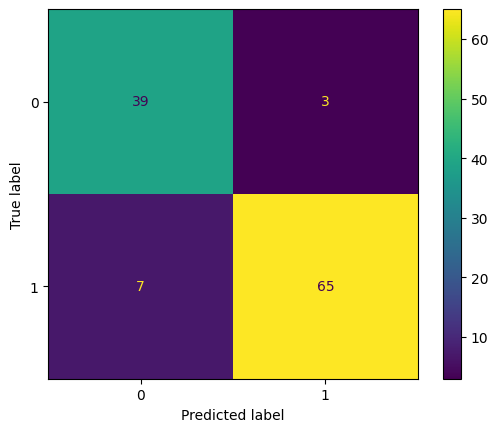

In [9]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#stratify=y
#This keeps the class proportions similar in both the training and test sets, 
# which is good practice for classification problems.

model = DecisionTreeRegressor(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1 Score : {f1:.3f}")


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()


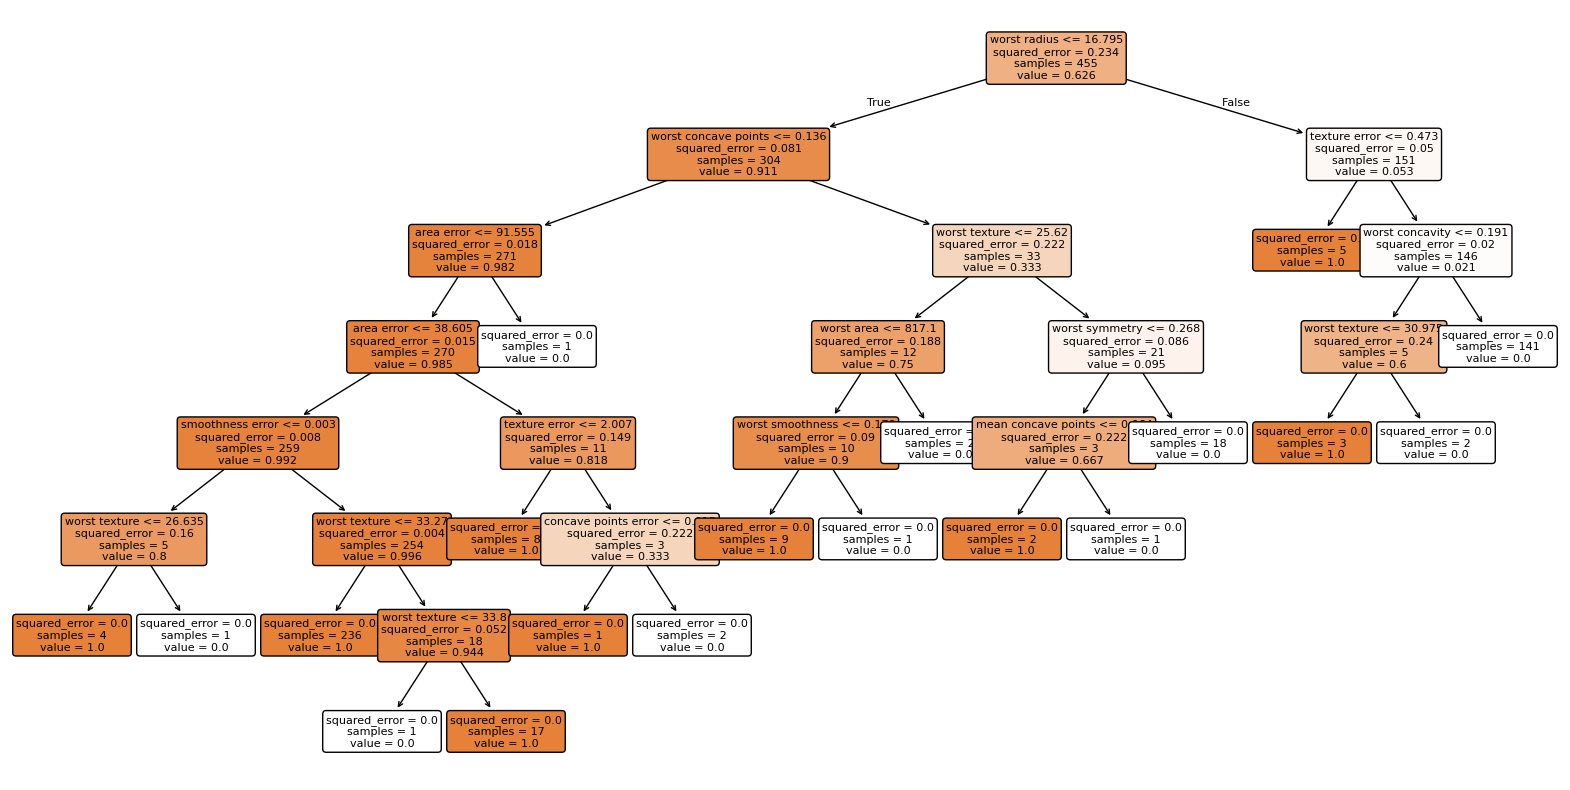

In [10]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

> **Feature Importance**

In [15]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
20,worst radius,0.697811
27,worst concave points,0.116083
21,worst texture,0.058881
11,texture error,0.052661
26,worst concavity,0.016325
23,worst area,0.012678
13,area error,0.012085
28,worst symmetry,0.010733
24,worst smoothness,0.008452
17,concave points error,0.006261


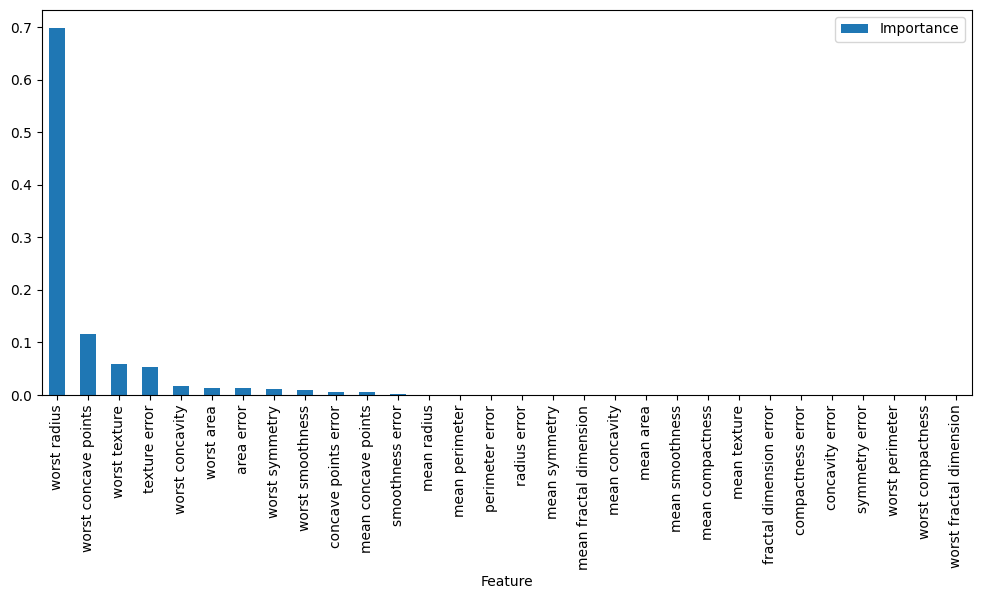

In [16]:
importance.plot.bar(
    x="Feature",
    y="Importance",
    figsize=(12,5)
)

plt.xticks(rotation=90)

plt.show()

**Expiriment**

In [17]:
for depth in [2, 3, 5, 10]:
    
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    print(f"Depth {depth}: {accuracy:.3f}")

Depth 2: 0.895
Depth 3: 0.939
Depth 5: 0.921
Depth 10: 0.912


Depth 3 gives that best accuracy 